# Exploración y limpieza de datos

En este notebook se realiza la exploración y limpieza inicial del dataset de coberturas administrativas de vacunación por departamento en Colombia.

El proceso incluye:

1. Carga del dataset.
2. Exploración inicial.
3. Revisión de valores nulos y duplicados.
4. Limpieza de nombres de columnas.
5. Corrección de textos.
6. Análisis de la variable de cobertura.
7. Corrección de valores atípicos.
8. Creación de una variable objetivo para clasificación.
9. Exportación del dataset limpio.

In [10]:
# Importar librerías principales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de gráficos
sns.set_theme(style="whitegrid")

# Para que los resultados sean reproducibles
np.random.seed(42)

In [11]:
# Cargar el archivo Excel desde la carpeta Datos

ruta = "Datos/Coberturas_administrativas_de_vacunación_por_departamento_20260521.xlsx"

df = pd.read_excel(ruta)

# Mostrar las primeras filas
df.head()

,CodDepto,Departamento,Año,Biológico,Cobertura_de_Vacunación,Indicator1_StateName,Indicator1_ThreeSymbolUnCircledCross_StartValue,Indicator1_ThreeSymbolUnCircledCross_EndValue,Indicator1_ThreeSymbolUnCircledExclamation_StartValue,Indicator1_ThreeSymbolUnCircledExclamation_EndValue,Indicator1_ThreeSymbolUnCircledCheck_StartValue,Indicator1_ThreeSymbolUnCircledCheck_EndValue
0,5,Antioquia,2019,BCG - Antituberculosa ReciÃ©n Nacido,0.9389,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99
1,8,AtlÃ¡ntico,2019,BCG - Antituberculosa ReciÃ©n Nacido,10379.0000,IndicatorState3,0,49.99,80,89.99,90,94.99
2,11,BogotÃ¡ D.C.,2019,BCG - Antituberculosa ReciÃ©n Nacido,10105.0000,IndicatorState3,0,49.99,80,89.99,90,94.99
3,13,BolÃ­var,2019,BCG - Antituberculosa ReciÃ©n Nacido,0.7170,IndicatorState1,0,49.99,80,89.99,90,94.99
4,15,BoyacÃ¡,2019,BCG - Antituberculosa ReciÃ©n Nacido,0.9409,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99


In [12]:
# Tamaño del dataset

print("Filas y columnas del dataset:")
print(df.shape)

Filas y columnas del dataset:
(660, 12)


In [13]:
# Información general del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 12 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   CodDepto                                               660 non-null    int64  
 1   Departamento                                           660 non-null    str    
 2   Año                                                    660 non-null    int64  
 3   Biológico                                              660 non-null    str    
 4   Cobertura_de_Vacunación                                660 non-null    float64
 5   Indicator1_StateName                                   660 non-null    str    
 6   Indicator1_ThreeSymbolUnCircledCross_StartValue        660 non-null    int64  
 7   Indicator1_ThreeSymbolUnCircledCross_EndValue          660 non-null    float64
 8   Indicator1_ThreeSymbolUnCircledExclamation_StartValue  660 no

In [14]:
# Ver nombres de columnas originales

df.columns

Index(['CodDepto', 'Departamento', 'Año', 'Biológico',
       'Cobertura_de_Vacunación', 'Indicator1_StateName',
       'Indicator1_ThreeSymbolUnCircledCross_StartValue',
       'Indicator1_ThreeSymbolUnCircledCross_EndValue',
       'Indicator1_ThreeSymbolUnCircledExclamation_StartValue',
       'Indicator1_ThreeSymbolUnCircledExclamation_EndValue',
       'Indicator1_ThreeSymbolUnCircledCheck_StartValue',
       'Indicator1_ThreeSymbolUnCircledCheck_EndValue'],
      dtype='str')

## Exploración inicial

En esta etapa se revisa la estructura general del dataset, incluyendo el número de filas, columnas, tipos de datos y nombres originales de las variables.

Esto permite identificar ajustes necesarios antes de continuar con la limpieza y el modelado.

In [15]:
# Revisar valores nulos por columna

nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    "valores_nulos": nulos,
    "porcentaje_nulos": porcentaje_nulos
})

tabla_nulos

,valores_nulos,porcentaje_nulos
CodDepto,0,0.0
Departamento,0,0.0
Año,0,0.0
Biológico,0,0.0
Cobertura_de_Vacunación,0,0.0
Indicator1_StateName,0,0.0
Indicator1_ThreeSymbolUnCircledCross_StartValue,0,0.0
Indicator1_ThreeSymbolUnCircledCross_EndValue,0,0.0
Indicator1_ThreeSymbolUnCircledExclamation_StartValue,0,0.0
Indicator1_ThreeSymbolUnCircledExclamation_EndValue,0,0.0


In [16]:
# Revisar registros duplicados

duplicados = df.duplicated().sum()

print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 0


In [17]:
# Estadísticas descriptivas de variables numéricas

df.describe().round(2)

,CodDepto,Año,Cobertura_de_Vacunación,Indicator1_ThreeSymbolUnCircledCross_StartValue,Indicator1_ThreeSymbolUnCircledCross_EndValue,Indicator1_ThreeSymbolUnCircledExclamation_StartValue,Indicator1_ThreeSymbolUnCircledExclamation_EndValue,Indicator1_ThreeSymbolUnCircledCheck_StartValue,Indicator1_ThreeSymbolUnCircledCheck_EndValue
count,660.00,660.00,660.00,660.0,660.00,660.0,660.00,660.0,660.00
mean,52.15,2020.50,227.61,0.0,49.99,80.0,89.99,90.0,94.99
std,30.81,1.12,1545.68,0.0,0.00,0.0,0.00,0.0,0.00
min,5.00,2019.00,0.00,0.0,49.99,80.0,89.99,90.0,94.99
25%,20.00,2019.75,0.67,0.0,49.99,80.0,89.99,90.0,94.99
50%,52.00,2020.50,0.85,0.0,49.99,80.0,89.99,90.0,94.99
75%,81.00,2021.25,0.92,0.0,49.99,80.0,89.99,90.0,94.99
max,99.00,2022.00,12357.00,0.0,49.99,80.0,89.99,90.0,94.99


In [18]:
# Crear una copia del dataset original para realizar la limpieza

df_limpio = df.copy()

# Renombrar columnas para facilitar el trabajo en Python

df_limpio = df_limpio.rename(columns={
    "CodDepto": "cod_departamento",
    "Departamento": "departamento",
    "Año": "anio",
    "Biológico": "biologico",
    "Cobertura_de_Vacunación": "cobertura_vacunacion",
    "Indicator1_StateName": "estado_indicador",
    "Indicator1_ThreeSymbolUnCircledCross_StartValue": "rango_bajo_inicio",
    "Indicator1_ThreeSymbolUnCircledCross_EndValue": "rango_bajo_fin",
    "Indicator1_ThreeSymbolUnCircledExclamation_StartValue": "rango_medio_inicio",
    "Indicator1_ThreeSymbolUnCircledExclamation_EndValue": "rango_medio_fin",
    "Indicator1_ThreeSymbolUnCircledCheck_StartValue": "rango_adecuado_inicio",
    "Indicator1_ThreeSymbolUnCircledCheck_EndValue": "rango_adecuado_fin"
})

df_limpio.head()

,cod_departamento,departamento,anio,biologico,cobertura_vacunacion,estado_indicador,rango_bajo_inicio,rango_bajo_fin,rango_medio_inicio,rango_medio_fin,rango_adecuado_inicio,rango_adecuado_fin
0,5,Antioquia,2019,BCG - Antituberculosa ReciÃ©n Nacido,0.9389,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99
1,8,AtlÃ¡ntico,2019,BCG - Antituberculosa ReciÃ©n Nacido,10379.0000,IndicatorState3,0,49.99,80,89.99,90,94.99
2,11,BogotÃ¡ D.C.,2019,BCG - Antituberculosa ReciÃ©n Nacido,10105.0000,IndicatorState3,0,49.99,80,89.99,90,94.99
3,13,BolÃ­var,2019,BCG - Antituberculosa ReciÃ©n Nacido,0.7170,IndicatorState1,0,49.99,80,89.99,90,94.99
4,15,BoyacÃ¡,2019,BCG - Antituberculosa ReciÃ©n Nacido,0.9409,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99


## Limpieza de nombres de columnas

Los nombres originales de las columnas contenían tildes, mayúsculas y textos extensos.

Por esta razón, se renombraron las variables usando minúsculas y guion bajo. Esto facilita el uso del dataset en Python y mejora la lectura del código.

In [32]:
# Corrección manual de caracteres mal codificados

reemplazos = {
    "Ã¡": "á",
    "Ã©": "é",
    "Ã­": "í",
    "Ã³": "ó",
    "Ãº": "ú",
    "Ã±": "ñ",
    "Ã": "Á",
    "Ã‰": "É",
    "Ã": "Í",
    "Ã“": "Ó",
    "Ãš": "Ú",
    "Ã‘": "Ñ",
    "Â": ""
}

def corregir_caracteres(texto):
    if isinstance(texto, str):
        for caracter_malo, caracter_bueno in reemplazos.items():
            texto = texto.replace(caracter_malo, caracter_bueno)
    return texto

columnas_texto = ["departamento", "biologico", "estado_indicador"]

for columna in columnas_texto:
    df_limpio[columna] = df_limpio[columna].apply(corregir_caracteres)

# Revisar nuevamente los biológicos únicos
print("Biológicos corregidos:")
print(df_limpio["biologico"].unique())

Biológicos corregidos:
<ArrowStringArray>
[                  'BCG - Antituberculosa Recién Nacido',
         'PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis',
               'N2D - Neumococo Mayor a 1 Año 2a. Dosis',
 'TV - Sarampión-Rubéola-Paperas (TV) 1 Año Única Dosis',
 'TV.R - Sarampión-Rubéola-Paperas (TV) 5 Años Refuerzo',
                                                'PENTA3',
                'N2D  Neumococo Mayor a 1 Año 2a. Dosis']
Length: 7, dtype: str


In [33]:
# Revisar departamentos únicos

print("Departamentos:")
print(df_limpio["departamento"].unique())

Departamentos:
<ArrowStringArray>
[                                               'Antioquia',
                                                'Atlántico',
                                             'Bogotá  D.C.',
                                                  'Bolívar',
                                                   'Boyacá',
                                                   'Caldas',
                                                  'Caquetá',
                                                    'Cauca',
                                                    'Cesar',
                                                  'Córdoba',
                                             'Cundinamarca',
                                                    'Chocó',
                                                    'Huila',
                                               'La Guajira',
                                                'Magdalena',
                                                   

In [34]:
# Revisar biológicos únicos

print("Biológicos:")
print(df_limpio["biologico"].unique())

Biológicos:
<ArrowStringArray>
[                  'BCG - Antituberculosa Recién Nacido',
         'PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis',
               'N2D - Neumococo Mayor a 1 Año 2a. Dosis',
 'TV - Sarampión-Rubéola-Paperas (TV) 1 Año Única Dosis',
 'TV.R - Sarampión-Rubéola-Paperas (TV) 5 Años Refuerzo',
                                                'PENTA3',
                'N2D  Neumococo Mayor a 1 Año 2a. Dosis']
Length: 7, dtype: str


## Corrección de textos

Durante la exploración se identificaron errores de codificación en algunas variables de texto.

Por ejemplo, algunos nombres podían aparecer con caracteres incorrectos. La corrección de estos textos permite evitar que una misma categoría sea interpretada como valores diferentes.

In [35]:
# Distribución de registros por año

conteo_anio = df_limpio["anio"].value_counts().sort_index()

conteo_anio

anio
2019    165
2020    165
2021    165
2022    165
Name: count, dtype: int64

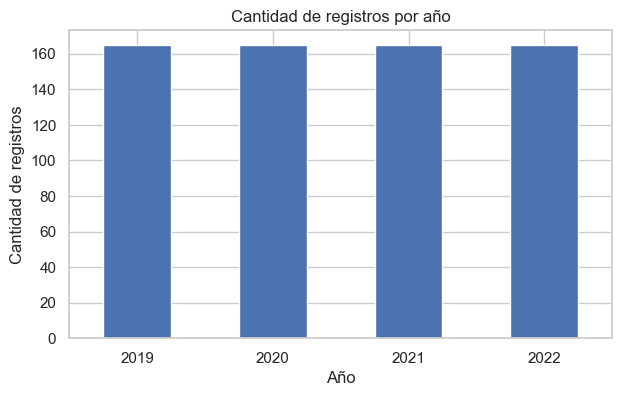

In [36]:
# Gráfico de registros por año

plt.figure(figsize=(7, 4))
conteo_anio.plot(kind="bar")

plt.title("Cantidad de registros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)

plt.show()

In [37]:
# Distribución de registros por biológico

conteo_biologico = df_limpio["biologico"].value_counts()

conteo_biologico

biologico
BCG - Antituberculosa Recién Nacido                      132
TV - Sarampión-Rubéola-Paperas (TV) 1 Año Única Dosis    132
TV.R - Sarampión-Rubéola-Paperas (TV) 5 Años Refuerzo    132
PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis             99
N2D - Neumococo Mayor a 1 Año 2a. Dosis                   99
PENTA3                                                    33
N2D  Neumococo Mayor a 1 Año 2a. Dosis                    33
Name: count, dtype: int64

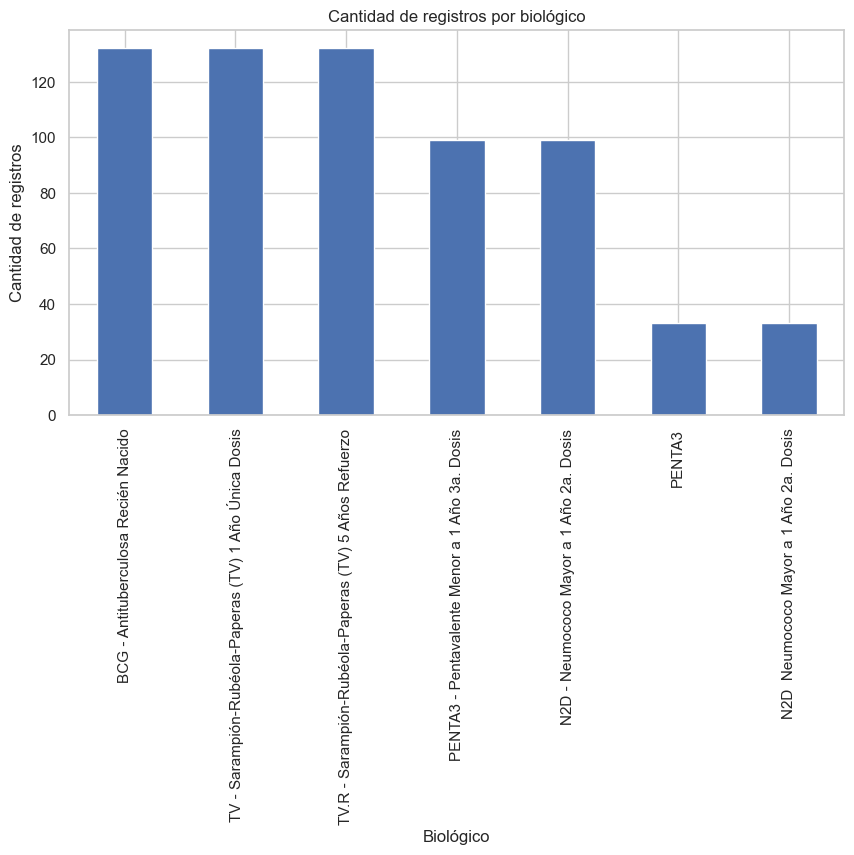

In [38]:
# Gráfico de registros por biológico

plt.figure(figsize=(10, 5))
conteo_biologico.plot(kind="bar")

plt.title("Cantidad de registros por biológico")
plt.xlabel("Biológico")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=90)

plt.show()

In [39]:
# Estadísticas de la cobertura de vacunación

df_limpio["cobertura_vacunacion"].describe().round(4)

count      660.0000
mean       227.6114
std       1545.6844
min          0.0000
25%          0.6662
50%          0.8453
75%          0.9160
max      12357.0000
Name: cobertura_vacunacion, dtype: float64

In [40]:
# Revisar los valores más altos de cobertura

df_limpio[[
    "departamento",
    "anio",
    "biologico",
    "cobertura_vacunacion",
    "estado_indicador"
]].sort_values(
    by="cobertura_vacunacion",
    ascending=False
).head(20)

,departamento,anio,biologico,cobertura_vacunacion,estado_indicador
29,Guainía,2019,BCG - Antituberculosa Recién Nacido,12357.0000,IndicatorState3
57,Arauca,2019,PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis,11514.0000,IndicatorState3
24,Arauca,2019,BCG - Antituberculosa Recién Nacido,11367.0000,IndicatorState3
13,La Guajira,2019,BCG - Antituberculosa Recién Nacido,11051.0000,IndicatorState3
62,Guainía,2019,PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis,10923.0000,IndicatorState3
123,Arauca,2019,TV - Sarampión-Rubéola-Paperas (TV) 1 Año Únic...,10873.0000,IndicatorState3
19,Risaralda,2019,BCG - Antituberculosa Recién Nacido,10422.0000,IndicatorState3
1,Atlántico,2019,BCG - Antituberculosa Recién Nacido,10379.0000,IndicatorState3
63,Guaviare,2019,PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis,10289.0000,IndicatorState3
54,Sucre,2019,PENTA3 - Pentavalente Menor a 1 Año 3a. Dosis,10213.0000,IndicatorState3
